# Telecom Customer Churn Prediction

## I.Introduction

**_What is customer churn?_**

Customer churn occurs when a customer ends their relationship with a company by canceling a subscription or switching to a competitor. It is typically measured using the customer churn rate, which represents the percentage of customers lost over a specific period. This metric is a key indicator of customer satisfaction and overall business health.

**_Why focus on customer churn?_**

The telecommunications sector is a highly competitive market, with annual churn rates ranging from 15% to 25%. Acquiring new customers is also significantly more expensive—about five times the cost of retaining existing ones.
For this reason, it is essential for companies to understand the causes of customer churn so they can reduce it and accurately predict which customers are at high risk of leaving.

**_What does this bring to a company?_**

By forecasting high-risk customers, a company can direct its retention efforts and resources toward the individuals who need them most, in a cost-effective way.
Reducing churn not only protects the company’s market position but also enables growth by allowing more investment in new customer acquisition campaigns, expanding coverage, and strengthening customer loyalty.


### Check Virtual Environment

In [64]:
#List of anaconda virtual environment
! conda env list


# conda environments:
#
                       C:\Users\stanl\.ai-navigator\micromamba\envs\cpu
base                   C:\Users\stanl\anaconda3
DL                     C:\Users\stanl\anaconda3\envs\DL
ML                   * C:\Users\stanl\anaconda3\envs\ML



In [65]:
#List of packages of the current virtual environment
! conda list

# packages in environment at C:\Users\stanl\anaconda3\envs\ML:
#
# Name                       Version          Build               Channel
absl-py                      2.3.1            pypi_0              pypi
annotated-types              0.7.0            pypi_0              pypi
anyio                        4.10.0           py313haa95532_0
aom                          3.6.0            hd77b12b_0
argon2-cffi                  21.3.0           pyhd3eb1b0_0
argon2-cffi-bindings         25.1.0           py313h02ab6af_0
asttokens                    3.0.0            py313haa95532_0
astunparse                   1.6.3            pypi_0              pypi
async-lru                    2.0.5            py313haa95532_0
attrs                        25.4.0           py313haa95532_2
babel                        2.16.0           py313haa95532_0
beautifulsoup4               4.13.5           py313haa95532_0
blas                         1.0              mkl
bleach                       6.2.0            py

### Loading Libraries

In [66]:
# Python Useful Libraries
from typing import Union
import warnings
import pickle

#Data Management Libraries
import numpy as np
import pandas as pd

#Data Visualisation Libraries
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning Libraries
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.feature_selection import VarianceThreshold, RFECV
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.metrics import roc_auc_score, precision_score, recall_score, precision_recall_curve, f1_score, confusion_matrix, classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

### Loading Data

In [67]:
#Retrieve data from kaggle
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/TelecomCustomerChurn.csv')

In [68]:
#Visualise dataframe
df.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


In [69]:
#Dataframe copy
work_df = df.copy()
work_df

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


## II.Exploratory Data Analysis

Objective: Reach the best understanding of the dataset to define modelling strategy.

2.1 Shape Analysis

    Identify the target: "Churn".
    Number of line and columns:
        - Rows = 7043.
        - Columns: 21.
    Columns names and types:
        - customerID           object
        - Gender               object
        - SeniorCitizen         int64
        - Partner              object
        - Dependents           object
        - Tenure                int64
        - PhoneService         object
        - MultipleLines        object
        - InternetService      object
        - OnlineSecurity       object
        - OnlineBackup         object
        - DeviceProtection     object
        - TechSupport          object
        - StreamingTV          object
        - StreamingMovies      object
        - Contract             object
        - PaperlessBilling     object
        - PaymentMethod        object
        - MonthlyCharges      float64
        - TotalCharges         object
        - Churn                object

    Missing value: No missing values.


2.2 Background Analysis

    Target Visualisation:
        - No: 73%
        - Yes: 27%
        Close to the estimated annual customer rate of 15-25%.

    Understand the various features:
        - customerID           Client identification number.
        - Gender               Biological sexual organs.
        - SeniorCitizen        Elderly person (65+ years old), especially one who is retired and living on a pension.
        - Partner              A person or other entity that has an official, contractual relationship to share in the profits, losses, and business happenings of a venture.
        - Dependents           A person who relies on another, especially a family member, for financial support.
        - Tenure               The length of time (month) in contract with the company.
        - PhoneService         Mobile or fix line subscription.
        - MultipleLines        More than 1 communication line associate to the subscriber.
        - InternetService      Web line subcripstion.
        - OnlineSecurity       The practice of protecting internet-connected systems and data from cyberattacks, threats, and unauthorized access.
        - OnlineBackup         Rhe process of copying data to a remote, offsite location using the internet, typically to cloud-based servers.
        - DeviceProtection     Refer to securing electronic devices against cyber threats, or coverage for accidental damage, loss, or theft of a physical device.
        - TechSupport          Service provided to registered users/subscribers with help and advice about the company's products.
        - StreamingTV          Distributed digital television content via internet connection.
        - StreamingMovies      Distributed digital movies content via internet connection.
        - Contract             Period of the subscribers recurrent payment, usually monthly or yearly.
        - PaperlessBilling     The process of sending and receiving bills electronically, such as through email or an online account, instead of using traditional paper mail.
        - PaymentMethod        The specific way a customer transfers funds to a business or individual to pay for goods or services.
        - MonthlyCharges       Recurring costs for a service, membership, or subscription that are billed each calendar month.
        - TotalCharges         The whole amount of money owed, which is the sum of all individual costs for goods or services.
        - Churn                Customer churn subcription state.

    Visualise the relation between features and target (Plot/ Histogram / Boxplot):
        - Done.

    NaN Analysis:
        - 11 empty data in "TotalCharges" features.

    Identity the outliers:
        -No Outliers.

2.3 Null Hypothesis (H0)

        Are all the features (numerical and categorical) influence the target output ?

2.4 Initial Conclusion

        "Gender", "Partner", "Dependents", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "PaymentMethod", "SeniorCitizen", "Tenure", "MonthlyCharges", "TotalCharges" features validate the various features selection methods and show reel impact on the target ("Churn").


### 2.1 Shape Analysis

In [70]:
#Identify the target
columns_name = work_df.columns
columns_name

Index(['customerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [71]:
#Save the target name
target_name =  columns_name[-1]
print(f"Target name: {target_name}")

Target name: Churn


In [72]:
#Dataframe dimension
work_df.shape

(7043, 21)

In [73]:
#Columns name and types
data_types = work_df.dtypes
print(data_types)

customerID           object
Gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
Tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [74]:
#Column type distribution
data_types.value_counts()

object     18
int64       2
float64     1
Name: count, dtype: int64

In [75]:
#Missing Values
work_df.isna().sum()/df.shape[0]

customerID          0.0
Gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
Tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [76]:
work_df.isnull().sum()

customerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: >

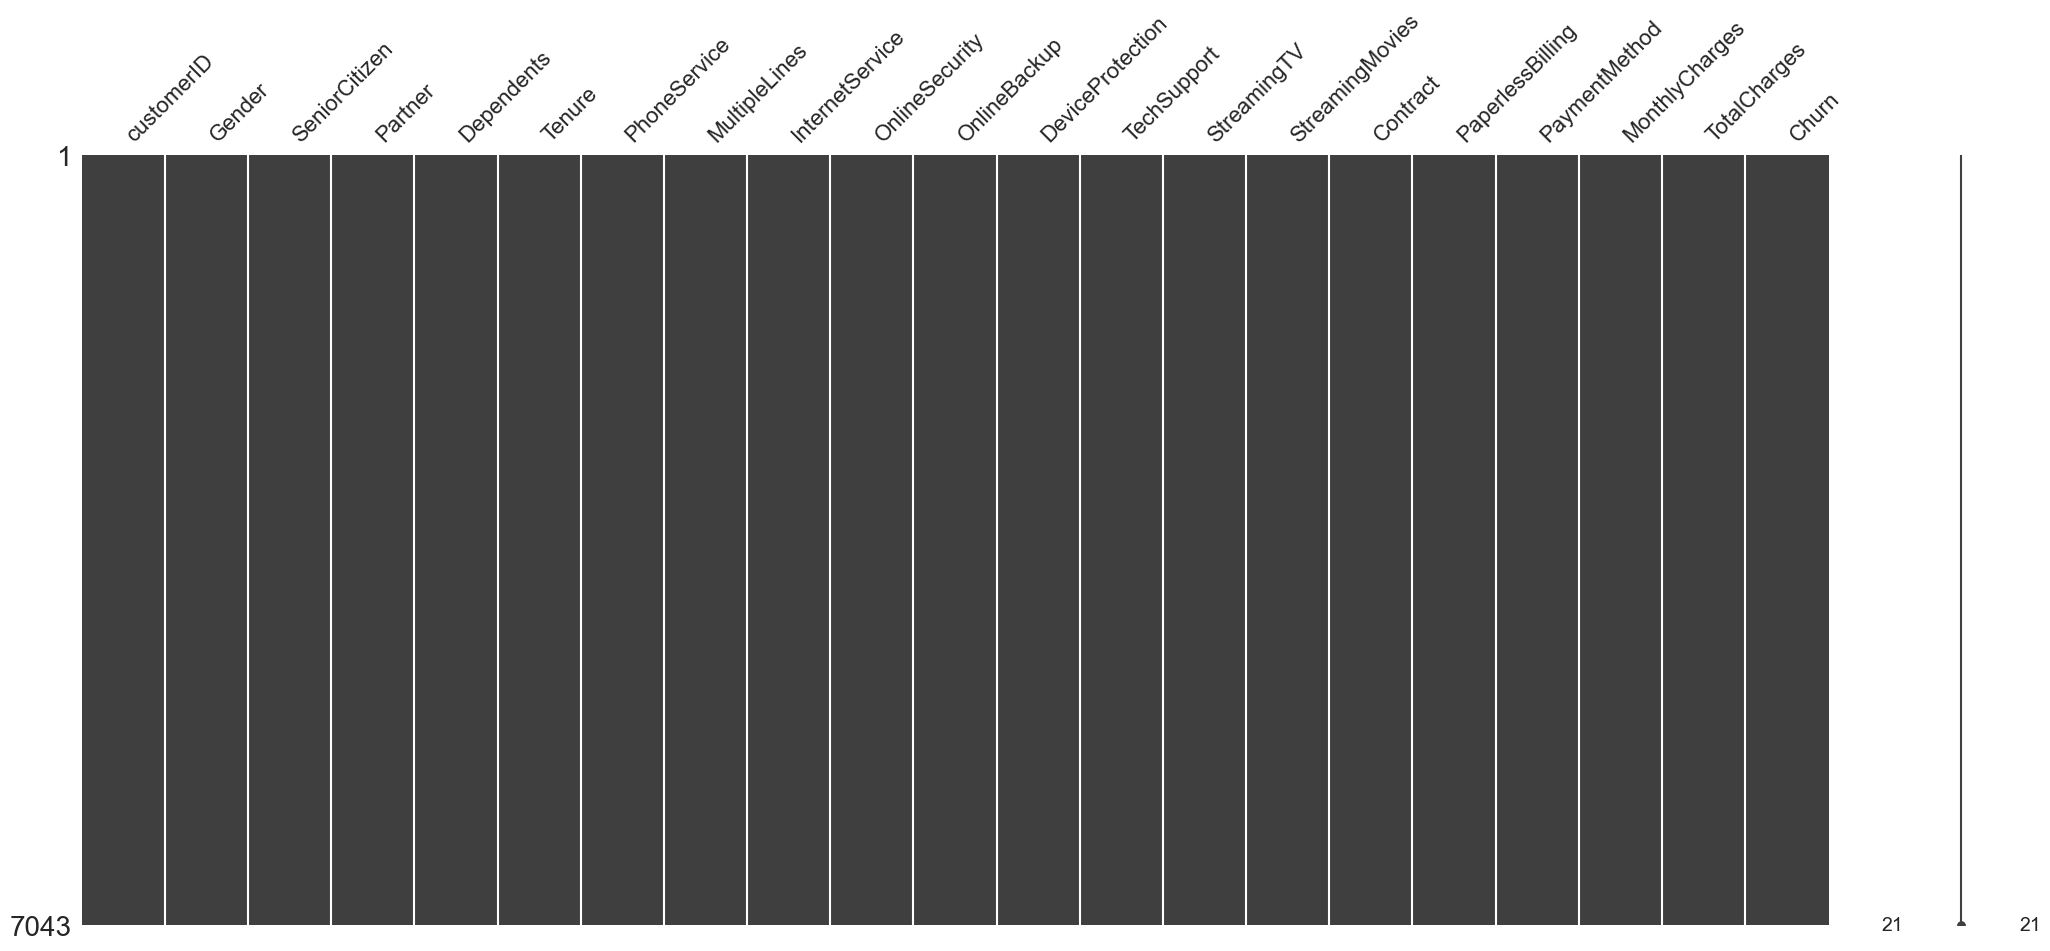

In [77]:
# Visualize missing values as a matrix
msno.matrix(work_df)

In [78]:
#Summarise Shape Analysis
work_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 2.2 Background Analysis

In [79]:
#Target Distribution
sr_target = work_df[target_name]
sr_target.value_counts(normalize= True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

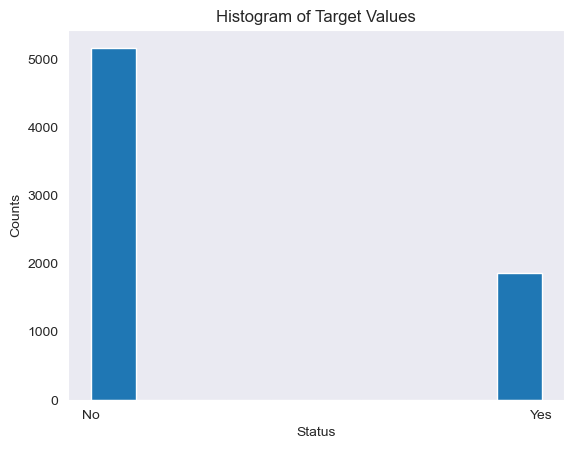

In [80]:
#Target Distribution Visualisation
plt.figure()
sr_target.hist()
plt.xlabel('Status')
plt.ylabel('Counts')
plt.title('Histogram of Target Values')
plt.grid(visible= False)
plt.show()

In [81]:
#Visualise the relation between features and target

#Seperate the columns types
numerical_columns  = work_df.select_dtypes(include= np.number).columns
categorial_columns = work_df.select_dtypes(include= np.object_).columns

numerical_columns = list(numerical_columns)
categorial_columns = list(categorial_columns)

In [82]:
#Delete the unnecessary feature and target from features
unnecessary_columns = ["customerID", target_name]

for column in unnecessary_columns:
    categorial_columns.remove(column)
categorial_columns

['Gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges']

In [83]:
#Check categorical features value distribution
for col in categorial_columns :
    print(f"{col:-<50} {work_df[col].unique()}")

Gender-------------------------------------------- ['Female' 'Male']
Partner------------------------------------------- ['Yes' 'No']
Dependents---------------------------------------- ['No' 'Yes']
PhoneService-------------------------------------- ['No' 'Yes']
MultipleLines------------------------------------- ['No' 'Yes']
InternetService----------------------------------- ['DSL' 'Fiber optic' 'No']
OnlineSecurity------------------------------------ ['No' 'Yes']
OnlineBackup-------------------------------------- ['Yes' 'No']
DeviceProtection---------------------------------- ['No' 'Yes']
TechSupport--------------------------------------- ['No' 'Yes']
StreamingTV--------------------------------------- ['No' 'Yes']
StreamingMovies----------------------------------- ['No' 'Yes']
Contract------------------------------------------ ['Monthly' 'One year' 'Two year']
PaperlessBilling---------------------------------- ['Yes' 'No']
PaymentMethod------------------------------------- ['Manual' 'Ba

In [84]:
#Found empty cell
for col in columns_name:
    print(f"{col} : {work_df[work_df[col] == " "].index}")

customerID : Index([], dtype='int64')
Gender : Index([], dtype='int64')
SeniorCitizen : Index([], dtype='int64')
Partner : Index([], dtype='int64')
Dependents : Index([], dtype='int64')
Tenure : Index([], dtype='int64')
PhoneService : Index([], dtype='int64')
MultipleLines : Index([], dtype='int64')
InternetService : Index([], dtype='int64')
OnlineSecurity : Index([], dtype='int64')
OnlineBackup : Index([], dtype='int64')
DeviceProtection : Index([], dtype='int64')
TechSupport : Index([], dtype='int64')
StreamingTV : Index([], dtype='int64')
StreamingMovies : Index([], dtype='int64')
Contract : Index([], dtype='int64')
PaperlessBilling : Index([], dtype='int64')
PaymentMethod : Index([], dtype='int64')
MonthlyCharges : Index([], dtype='int64')
TotalCharges : Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')
Churn : Index([], dtype='int64')


The empty are found inside the "TotalCharges" features.
Delete the missing values (11) rows as its will not affect the dataset.

In [85]:
#Delete empty rows in "TotalCharges"
work_df.drop(labels= work_df[work_df["TotalCharges"] == " "].index, axis= "index", inplace=True)
work_df

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


In [86]:
#Convert categorical features into numerical features
work_df["TotalCharges"] = work_df["TotalCharges"].map(lambda x: float(x))
print(f"\"TotalCharge\" types: {work_df["TotalCharges"].dtypes}")

"TotalCharge" types: float64


In [87]:
#Correct the numerical and categorical features list
numerical_columns.append("TotalCharges")
categorial_columns.remove("TotalCharges")

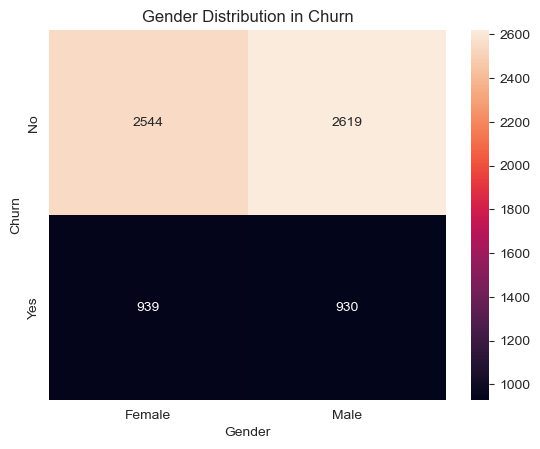

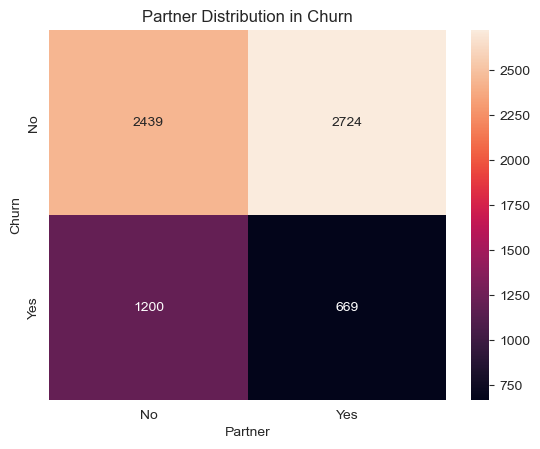

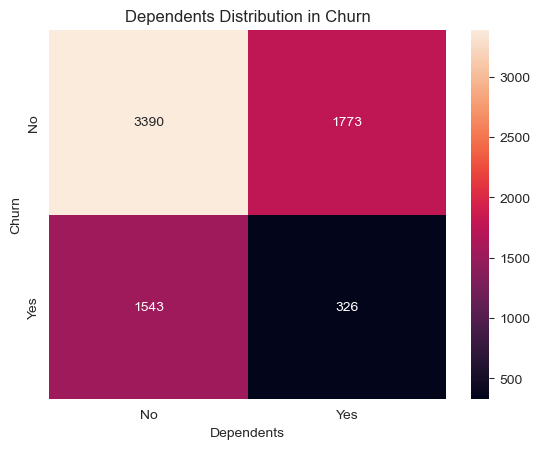

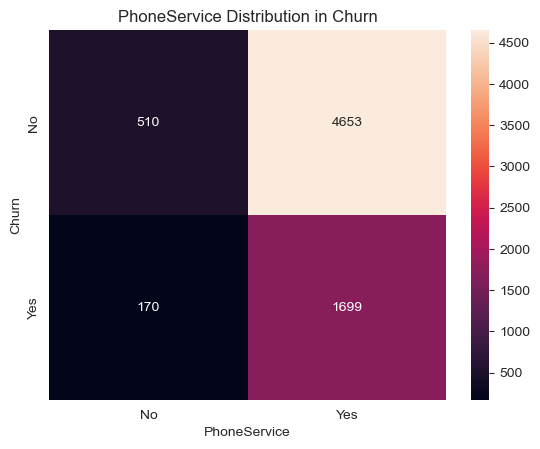

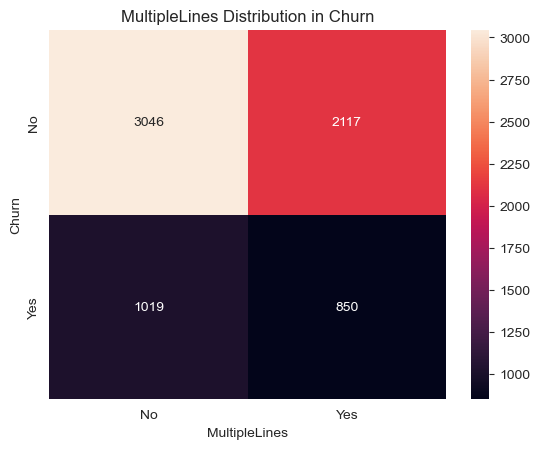

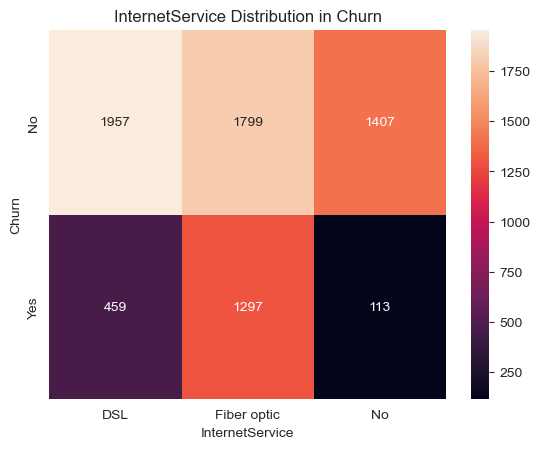

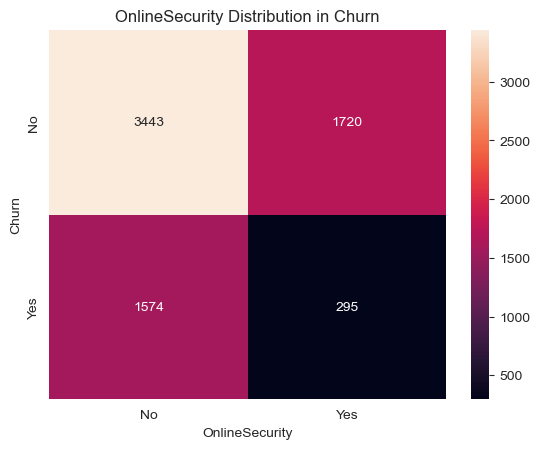

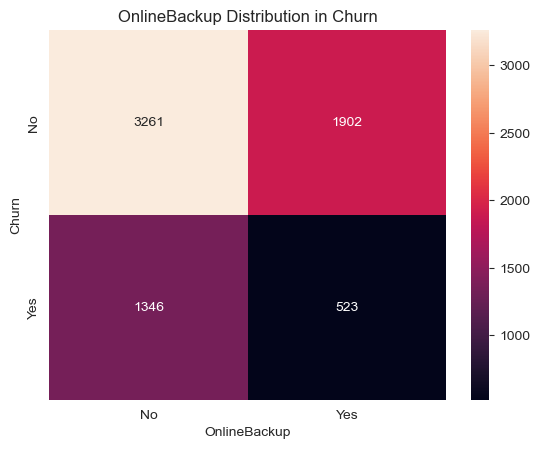

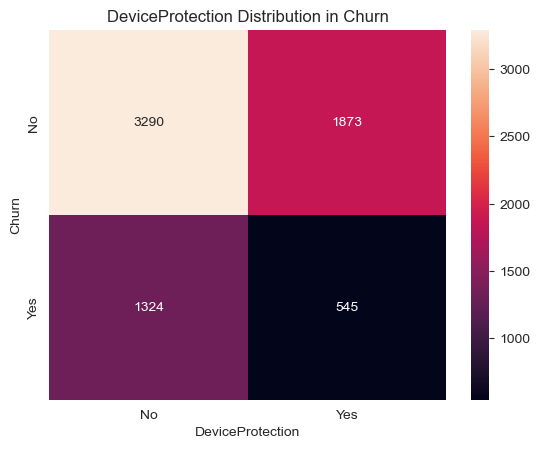

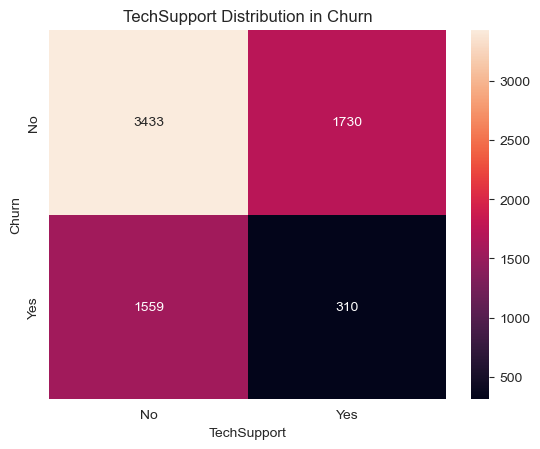

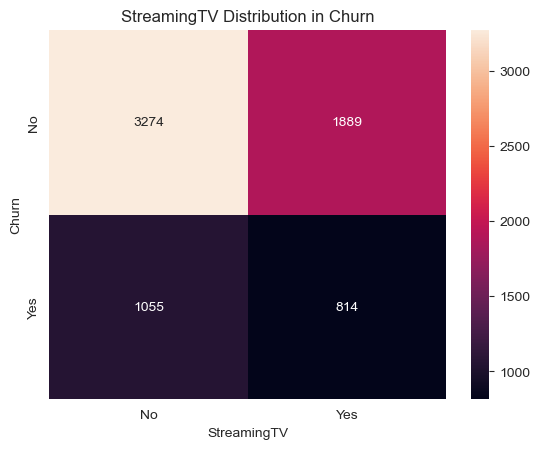

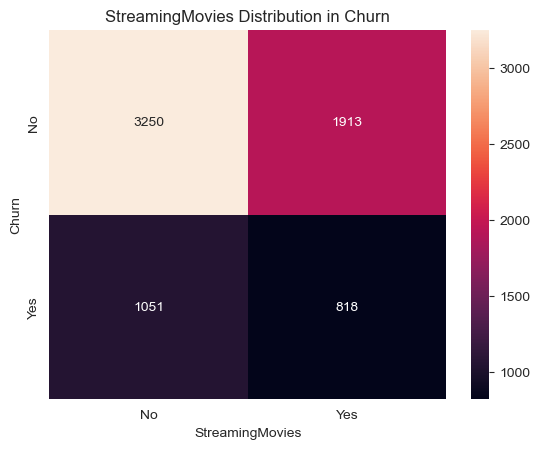

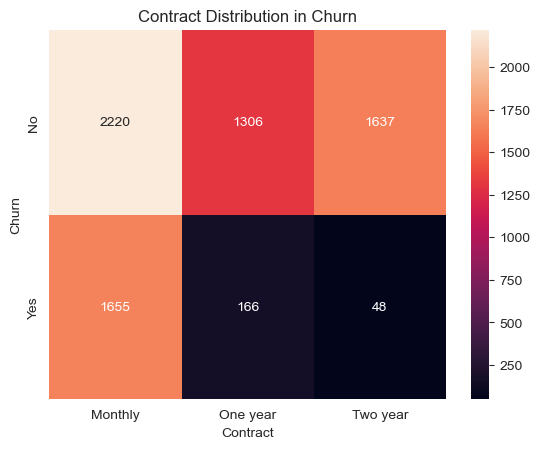

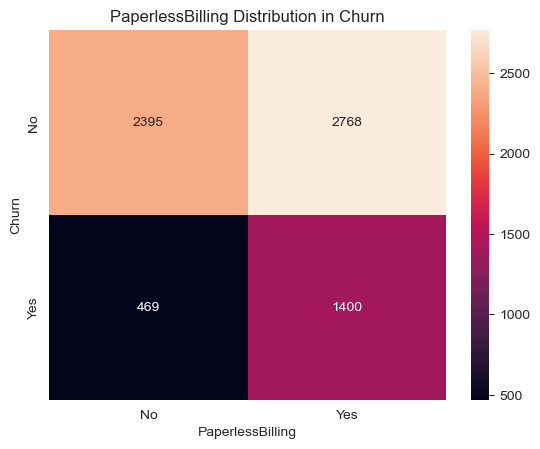

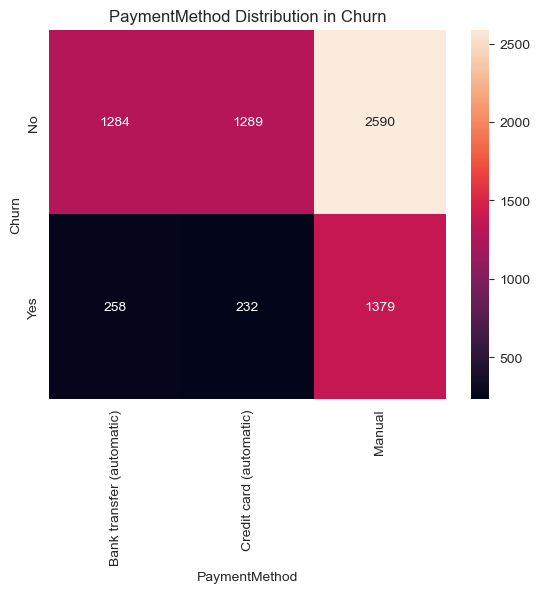

In [88]:
#Visualise the relationship between categorical features and target
for col in categorial_columns:
    plt.figure()
    sns.heatmap(pd.crosstab(work_df[target_name], work_df[col]), annot= True, fmt= 'd')
    plt.title(f"{col} Distribution in {target_name}")
    plt.show()

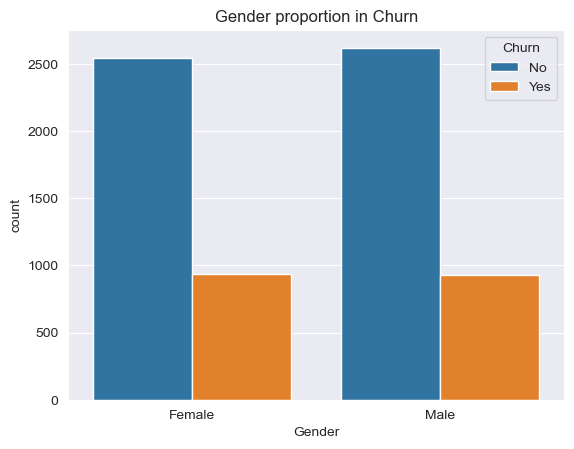

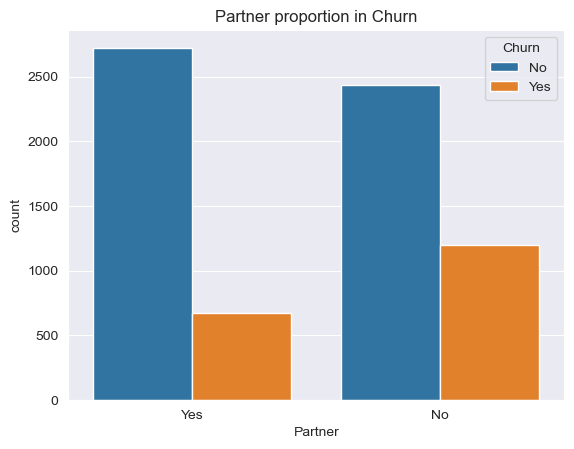

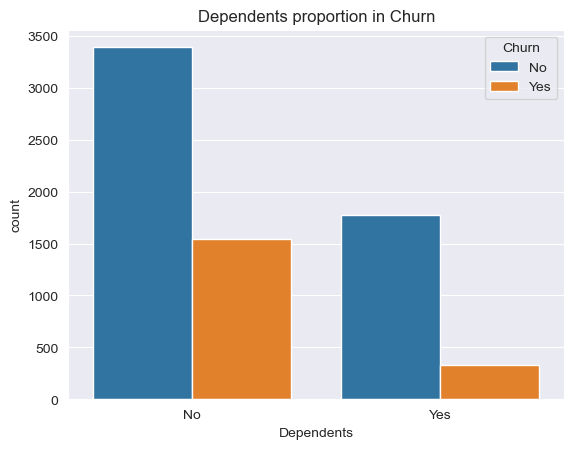

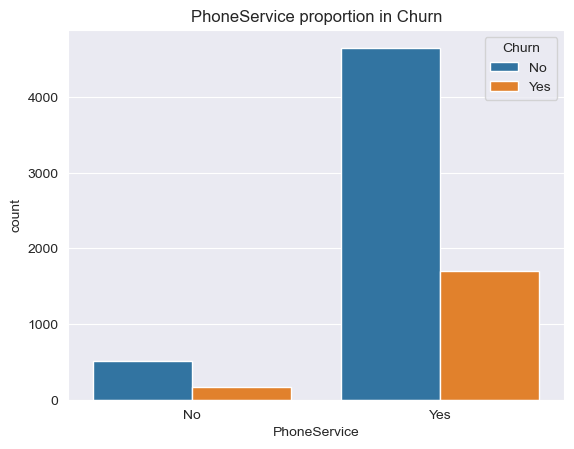

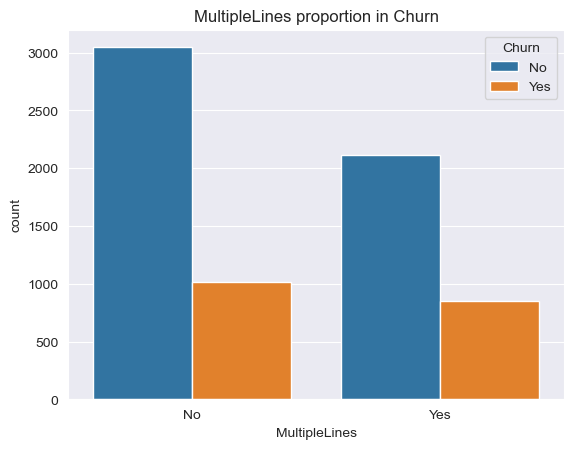

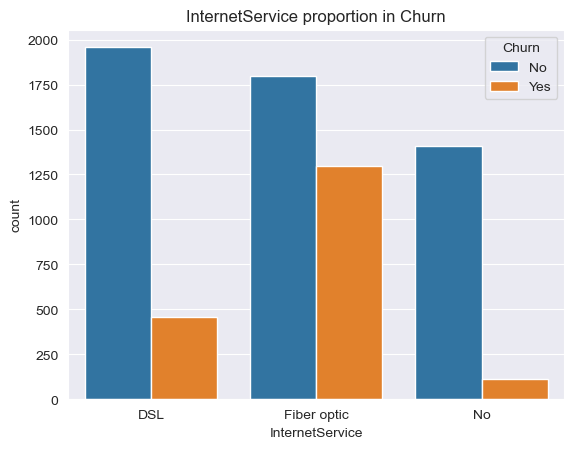

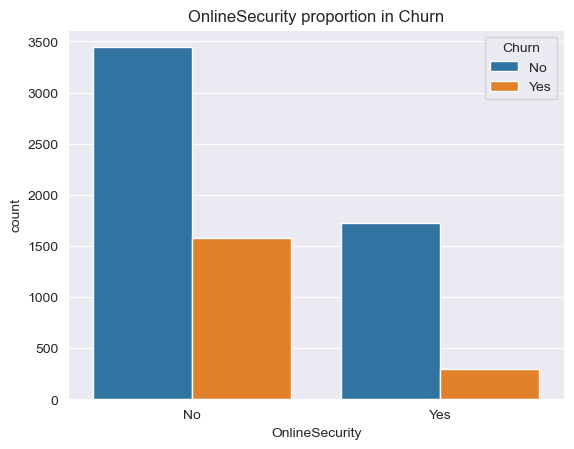

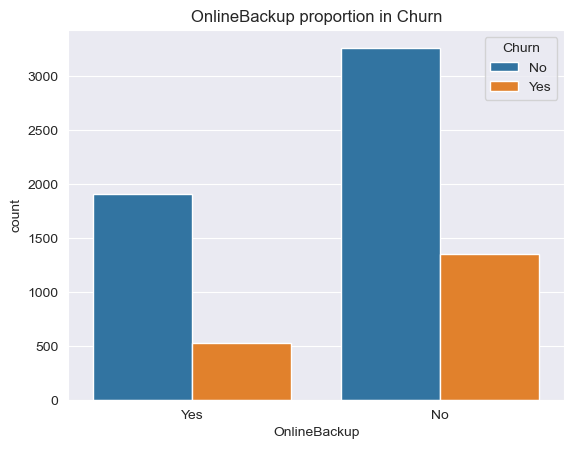

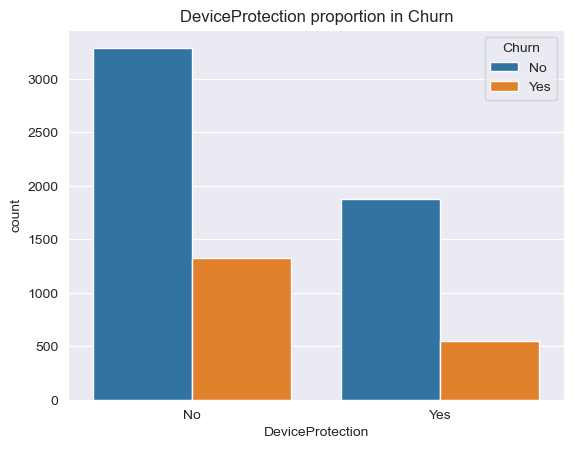

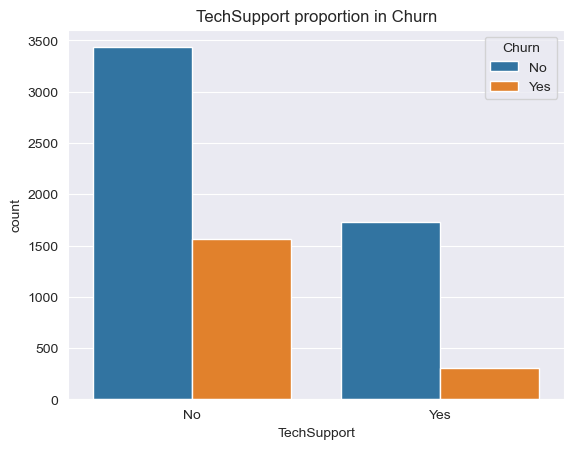

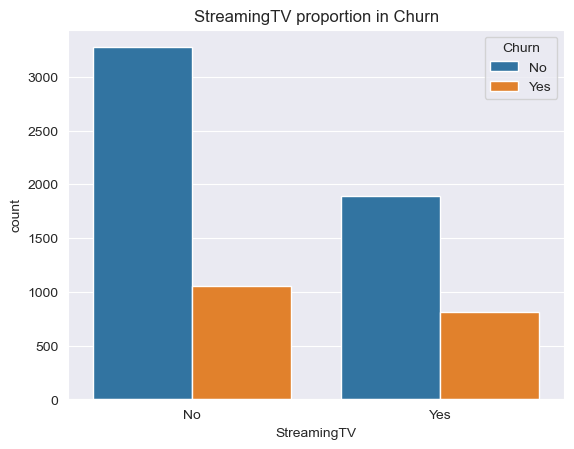

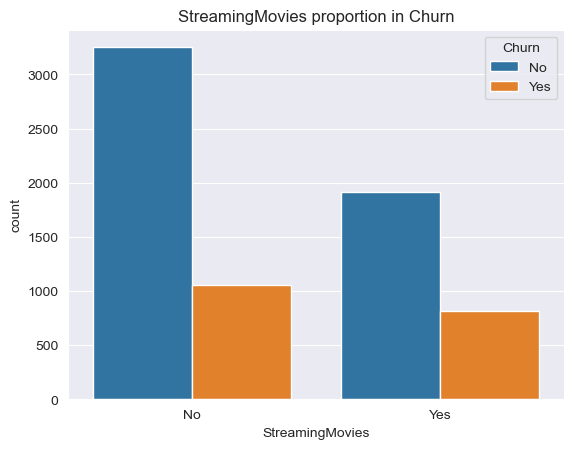

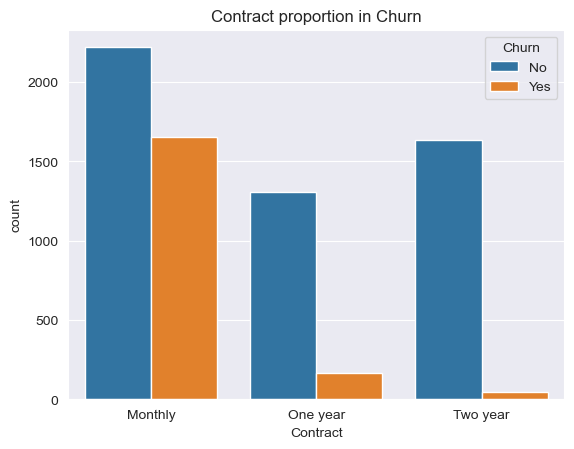

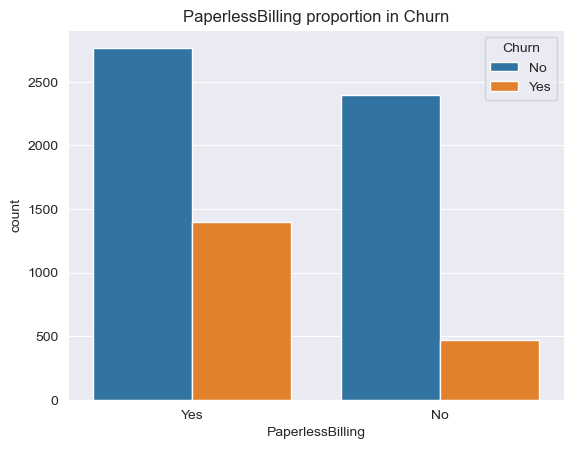

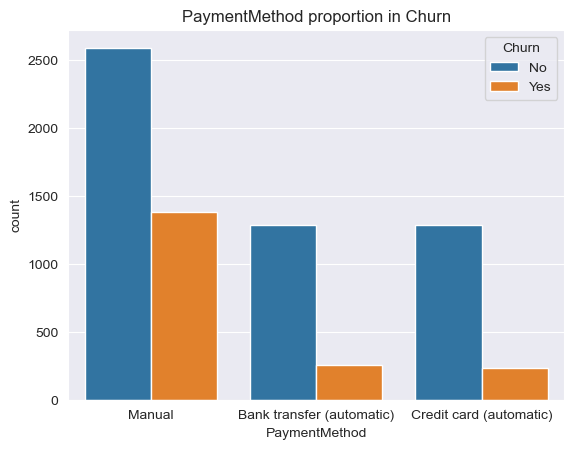

In [89]:
#Clearer representation
for col in categorial_columns:
    plt.figure()
    sns.countplot(data= work_df, x= col, hue= target_name)
    plt.title(f"{col} proportion in {target_name}")
    plt.show()

<Figure size 640x480 with 0 Axes>

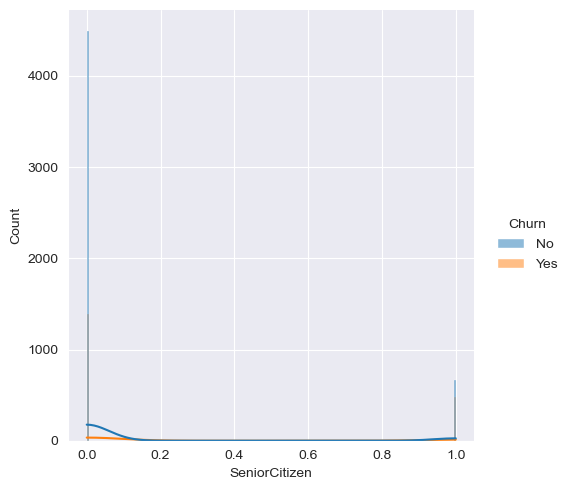

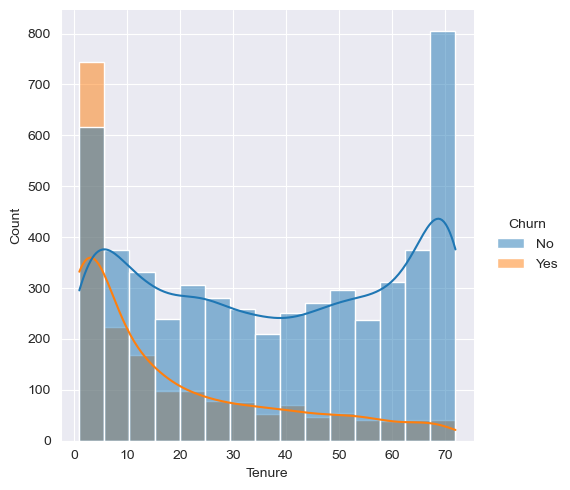

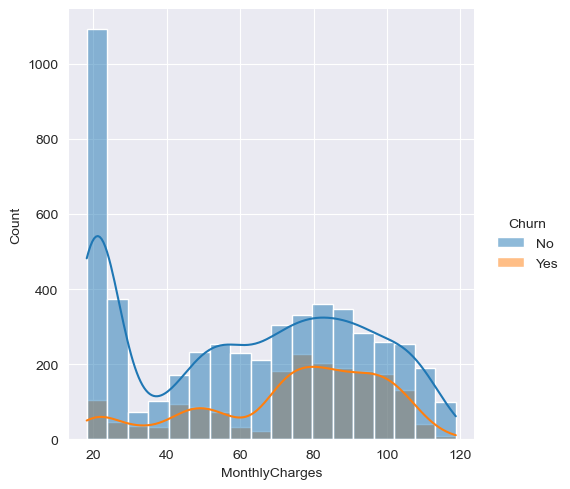

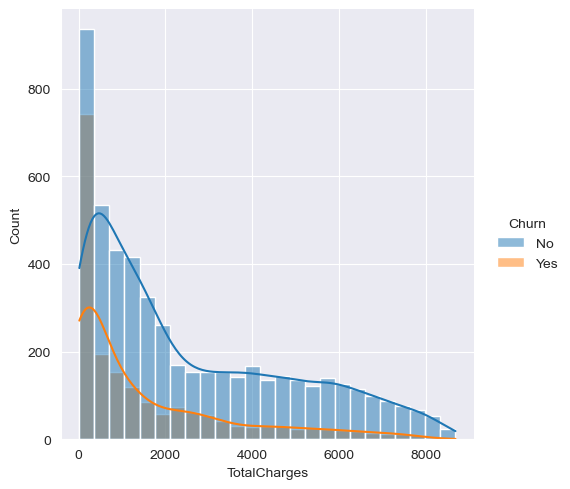

In [90]:
#Visualise the relationship between the numerical features and target
plt.figure()
for col in numerical_columns:
    sns.displot(data= work_df, x=col, kde= True, hue= target_name)
plt.show()

<Figure size 640x480 with 0 Axes>

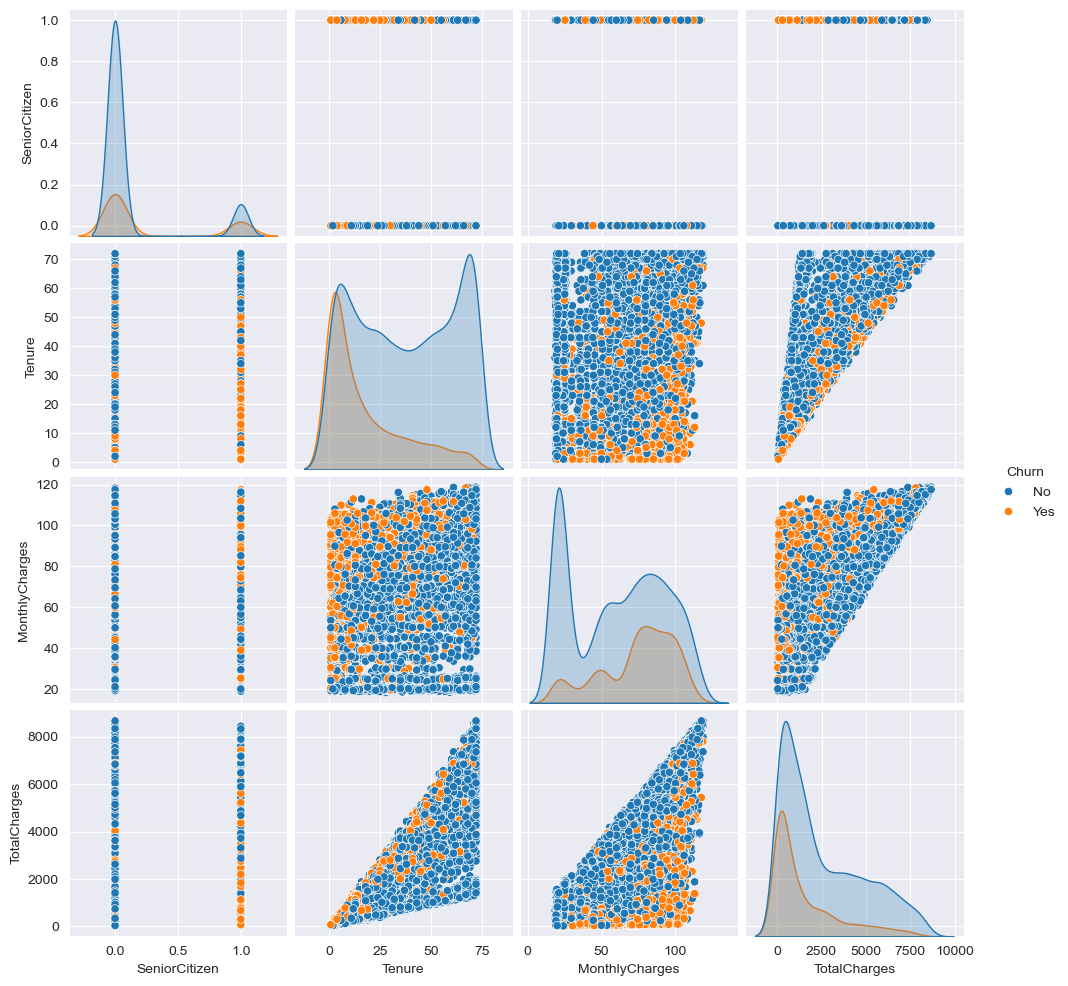

In [91]:
plt.figure()
sns.pairplot(data=work_df, hue= target_name)
plt.show()

<Figure size 640x480 with 0 Axes>

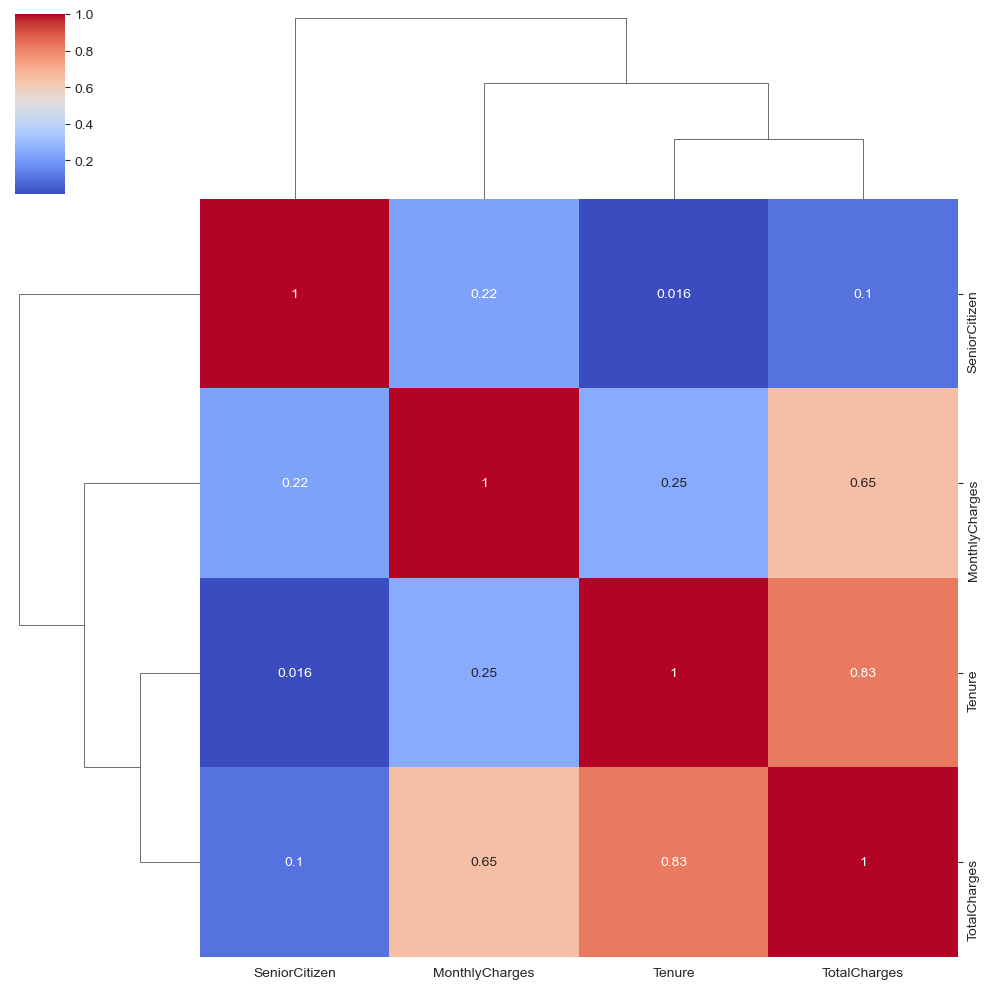

In [92]:
_#Visualise relationship between numerical features
plt.figure()
sns.clustermap(work_df[numerical_columns].corr(), cmap= 'coolwarm', annot= True)
plt.show()

In [93]:
#NaN Analysis
work_df[work_df == " "].notna().sum()

customerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [94]:
work_df.isna().sum()

customerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [95]:
#Identity the outliers: Interquartile Range (IQR) Method
for col in numerical_columns:

    #"SeniorCitizen" value are binary, so the IQR Method is not adapted.
    if col == "SeniorCitizen":
        continue

    q1 = np.quantile(work_df[col], 0.25)
    q3 = np.quantile(work_df[col], 0.75)
    IQR = q3 - q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    outliers = [x for x in work_df[col] if (x < lower_bound) or (x > upper_bound)]

    print(f"{col} Outliers: {outliers}")


Tenure Outliers: []
MonthlyCharges Outliers: []
TotalCharges Outliers: []


In [96]:
#Summarise the deep analysis
work_df.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## III.Data Preprocessing

In [97]:
#Start from clean dataframe
preprocess_df = df.copy()
preprocess_df

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


### Drop Missing Values

In [98]:
#Drop missing values
modify_feat = "TotalCharges"
preprocess_df.drop(labels= preprocess_df[preprocess_df[modify_feat] == " "].index, axis= 0, inplace= True)

In [99]:
#Convert the feature "TotalCharges".
preprocess_df[modify_feat]= preprocess_df[modify_feat].map(lambda x: float(x))
print(preprocess_df.dtypes)

customerID           object
Gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
Tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [100]:
#Retreive the features
X = preprocess_df.drop(unnecessary_columns, axis=1)
X

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Manual,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Manual,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Monthly,Yes,Manual,53.85,108.15
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Monthly,Yes,Manual,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Monthly,Yes,Manual,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Monthly,Yes,Manual,74.40,306.60


### Label Target

In [101]:
#Retrieve Target
target_sr = preprocess_df[target_name]
print(f"Target:\n{target_sr}")

Target:
0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7032, dtype: object


In [102]:
#Label Target
label_encoder  = LabelEncoder()
y = label_encoder.fit_transform(target_sr)
print(f"y: {y}")

y: [0 0 1 ... 0 1 0]


In [103]:
#Conversion table
for val in np.unique(y):
    print(f"{val} --> {label_encoder.inverse_transform([val])[0]}")

0 --> No
1 --> Yes


### Train/Test Split

In [104]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 15)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (5625, 19), y_train: (5625,)
X_test: (1407, 19), y_test: (1407,)


### Encoder Transformer

In [105]:
#Encode
categorial_transformer = make_column_selector(dtype_include=np.object_)
categorial_transformer

### Standardise Transformer

In [106]:
#Standardise
numerical_transformer = make_column_selector(dtype_include= np.number)
numerical_transformer

### Preprocessor Transformer

In [107]:
#Associate transformer to features
preprocessor = ColumnTransformer(
    transformers=[
        ("Num", StandardScaler(), numerical_transformer),
        ("Cat", OrdinalEncoder(), categorial_transformer),
    ]
)
preprocessor

,transformers,"[('Num', ...), ('Cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


##  IV.Modelling

*   Define the evaluation function
*   Train various model
  - Create different model (Gauss, KNeighors, SVM, Decision Tree, RandomForest [Bagging], AdaBoost or GradientBoosting [Boosting], Artificial Neural Network).
  - Select the most promising model (KNeighors, SVM, AdaBoost, GradientBoosting, Artificial Neural Network).
*   Optimise the model (GridSearchCV)
*   Analyse error and modify the pre-processing to achieve better performance.
*   Learning Curve and Decision from those performances.

**Conclusion:**



In [108]:
#Create Machine Learning Model

#Parameters
ml_names, ml_model = [], []

#Names
ml_names = ["Gauss", "K-Nearest Neighbors", "Support Vector Machine", "Decision Tree", "Random Forest",
            "AdaBoost", "GradientBoosting", "Artificial Neural Network"]
#Models
gauss             = GaussianNB()
knn               = KNeighborsClassifier(n_neighbors= 5)
svc               = SVC(random_state= 15, probability= True)
tree              = DecisionTreeClassifier(random_state= 15)
forest            = RandomForestClassifier(random_state= 15)
adaboost          = AdaBoostClassifier(random_state= 15)
gradient_boosting = GradientBoostingClassifier(random_state= 15)
ann               = MLPClassifier(random_state= 15)

In [109]:
#Create Evaluation Function
def evaluation(model, name: str= None):

    #Display model name
    print(f"Evaluating {name}")

    #Train the model
    model.fit(X_train, y_train)
    #Predict the output
    y_pred = model.predict(X_test)

    #Visualise the confusion matrix and classification report
    print(classification_report(y_test, y_pred))

    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot= True, fmt= 'g',)
    plt.show()

    #Learning Curve to visualise the system perform
    N, train_score, val_score = learning_curve(model,
                                               X_train,
                                               y_train,
                                               train_sizes= np.linspace(0.1, 1.0, 10),
                                               cv= 5,
                                               scoring= "recall",
    )
    plt.figure()
    plt.plot(N, train_score.mean(axis= 1), label="Training Score")
    plt.plot(N, val_score.mean(axis= 1), label="Validation Score")
    plt.legend(loc="best")
    plt.show()
    print()

### Test Model

In [110]:
#Test Evaluation
test_model = make_pipeline(preprocessor, tree)

Evaluating Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1040
           1       0.48      0.50      0.49       367

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



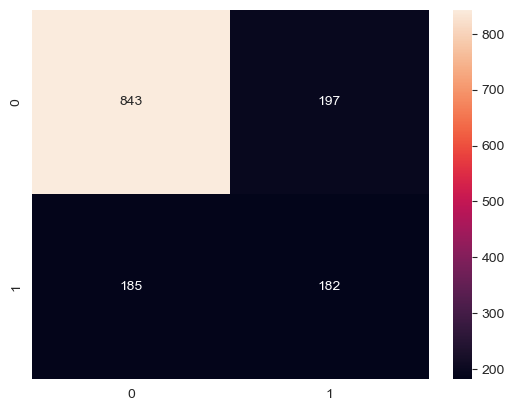

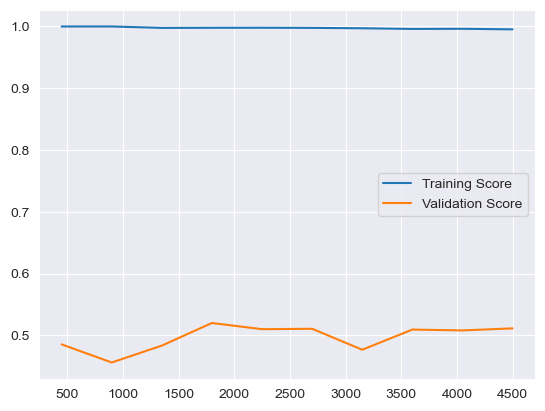

In [111]:
#Evaluate the model
evaluation(test_model, name="Decision Tree Classifier")

In [112]:
#Display Testing Score
print(f"Train Score: {test_model.score(X_train, y_train)}")
print(f"Testing Score: {test_model.score(X_test, y_test)}")

Train Score: 0.9984
Testing Score: 0.728500355366027


Testing Model is in clear overffiting with a great training perform (Acc: 1.0) and good testing score (Acc: 0.73)

## V.Features Selection

### Features weight

In [113]:
#Select the most import feature of the Decision Tree model
features_weight = pd.DataFrame(test_model.named_steps["decisiontreeclassifier"].feature_importances_, index= X.columns)
features_weight

,0
Gender,0.020250
SeniorCitizen,0.119171
Partner,0.235594
Dependents,0.215887
Tenure,0.025272
PhoneService,0.022642
MultipleLines,0.018759
InternetService,0.003249
OnlineSecurity,0.017814
OnlineBackup,0.021225


<Figure size 1200x1000 with 0 Axes>

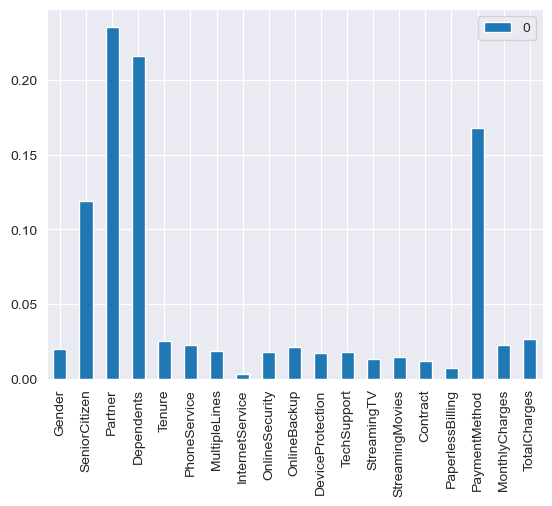

In [114]:
#Visualise Features Weight
plt.figure(figsize= (12,10))
features_weight.plot.bar()
plt.show()

The most influence features:

    - Partner (0.235594)
    - Dependents (0.215887)
    - PaymentMethod (0.167654)
    - SenoirCittizen (0.119171)

A threshold of acceptable weight for the features must be defined --> 0.015

In [115]:
#Display the features
features_weight[features_weight >= 0.015]

,0
Gender,0.020250
SeniorCitizen,0.119171
Partner,0.235594
Dependents,0.215887
Tenure,0.025272
PhoneService,0.022642
MultipleLines,0.018759
InternetService,NaN
OnlineSecurity,0.017814
OnlineBackup,0.021225


Select features:

    - Categorial: Gender, Partner, Dependents, PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, PaymentMethod.
    - Numerical: SeniorCitizen, Tenure, MonthlyCarges, TotalCharges.

### Features encoding and scaling

In [116]:
#Retrieve numerical and categorical columns list
#Parameter
num_col, cat_col = [], []
for col in X_train.columns:
    if X_train.dtypes[col] == np.object_:
        cat_col.append(col)
    else:
        num_col.append(col)

print(f"Numerical columns: {num_col}")
print(f"Categorical columns: {cat_col}")

Numerical columns: ['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [117]:
#Encode the categorical columns
ord_encoder = OrdinalEncoder()
X_train_cat_encoded = pd.DataFrame(ord_encoder.fit_transform(X_train[cat_col]), columns = cat_col)
X_train_cat_encoded

,Gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
2,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
4,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
5621,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5622,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
5623,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [118]:
#Standardise the numerical columns
std_scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(std_scaler.fit_transform(X_train[num_col]), columns = num_col)
X_train_num_scaled

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
0,2.235353,-0.957112,0.357818,-0.726558
1,-0.447357,-1.285285,0.153356,-0.979882
2,-0.447357,-0.382810,0.568929,-0.203253
3,2.235353,1.134989,0.539008,1.156127
4,-0.447357,-1.203242,-1.480677,-0.981398
...,...,...,...,...
5620,-0.447357,-0.710983,-0.438420,-0.669431
5621,-0.447357,-0.998134,-1.502287,-0.938943
5622,-0.447357,1.545205,1.692639,2.542933
5623,-0.447357,-1.244264,-1.492313,-0.987798


In [119]:
X_train_encoded = pd.concat([X_train_cat_encoded, X_train_num_scaled], axis= 1)
X_train_encoded

,Gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.235353,-0.957112,0.357818,-0.726558
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,-0.447357,-1.285285,0.153356,-0.979882
2,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.447357,-0.382810,0.568929,-0.203253
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.235353,1.134989,0.539008,1.156127
4,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.447357,-1.203242,-1.480677,-0.981398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.447357,-0.710983,-0.438420,-0.669431
5621,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.447357,-0.998134,-1.502287,-0.938943
5622,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,-0.447357,1.545205,1.692639,2.542933
5623,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-0.447357,-1.244264,-1.492313,-0.987798


### Variance Threshold Test

In [120]:
#Variance Threshold
threshold = 0.20
selector_var = VarianceThreshold(threshold= threshold)
selector_var.fit(X_train_encoded)
X_train_encoded.columns[selector_var.get_support()]

Index(['Gender', 'Partner', 'Dependents', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'SeniorCitizen', 'Tenure', 'MonthlyCharges',
       'TotalCharges'],
      dtype='object')

All the features listed have a variance superior or equal at 0.20.
And of the most influence features are present (Partner, Dependents, PaymentMethod, SeniorCitizen, Tenure and TotalCharges).

### Recursive Features Elimination Cross Validation Test

In [121]:
#Recursive Features Elimination Cross Validation
selector_rfecv = RFECV(DecisionTreeClassifier(random_state= 15), step= 0.2, n_jobs= -1, scoring= 'roc_auc', cv= 5, min_features_to_select= 6)
selector_rfecv.fit(X_train_encoded, y_train)

,estimator,DecisionTreeC...ndom_state=15)
,step,0.2
,min_features_to_select,6
,cv,5
,scoring,'roc_auc'
,verbose,0
,n_jobs,-1
,importance_getter,'auto'
,criterion,'gini'
,splitter,'best'
,max_depth,None


In [122]:
for i, feat in zip(selector_rfecv.ranking_, X_train_encoded.columns):
    print(f"Feature {i}: {feat}")

Feature 1: Gender
Feature 1: Partner
Feature 1: Dependents
Feature 2: PhoneService
Feature 1: MultipleLines
Feature 1: InternetService
Feature 1: OnlineSecurity
Feature 1: OnlineBackup
Feature 1: DeviceProtection
Feature 1: TechSupport
Feature 2: StreamingTV
Feature 2: StreamingMovies
Feature 1: Contract
Feature 1: PaperlessBilling
Feature 1: PaymentMethod
Feature 1: SeniorCitizen
Feature 1: Tenure
Feature 1: MonthlyCharges
Feature 1: TotalCharges


In [123]:
#Retrieve the RFECV selected features
rfecv_selected_features = selector_rfecv.get_feature_names_out()

#Display the RFECV selected features
print(" RFECV Selected Features: ", rfecv_selected_features)

 RFECV Selected Features:  ['Gender' 'Partner' 'Dependents' 'MultipleLines' 'InternetService'
 'OnlineSecurity' 'OnlineBackup' 'DeviceProtection' 'TechSupport'
 'Contract' 'PaperlessBilling' 'PaymentMethod' 'SeniorCitizen' 'Tenure'
 'MonthlyCharges' 'TotalCharges']


This is a confirmation that the features ('Gender', 'Partner', 'Dependents', 'MultipleLines','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges') are listed into the most influent ones.

### Selected Features

The features present in the various features selection methods are:

    - Categorial: Gender, Partner, Dependents, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, PaymentMethod.
    - Numerical: SeniorCitizen, Tenure, MonthlyCharges, TotalCharges.

In [124]:
#Modify the training and testing set
selected_features = ["Gender", "Partner", "Dependents", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "PaymentMethod", "SeniorCitizen", "Tenure", "MonthlyCharges", "TotalCharges"]
X = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 15)

#Display the new training and testing set shape
print(f"Training features data shape: {X_train.shape}")
print(f"Test features data shape: {X_test.shape}")
print(f"Training target data shape: {y_train.shape}")
print(f"Test target data shape: {y_test.shape}")

Training features data shape: (5625, 13)
Test features data shape: (1407, 13)
Training target data shape: (5625,)
Test target data shape: (1407,)


## VI.Model Evaluation

In [125]:
#Redefine the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("Num", StandardScaler(), ["Tenure", "MonthlyCharges", "TotalCharges"]),
        ("Cat", OrdinalEncoder(), ["Gender", "Partner", "Dependents", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "PaymentMethod"]),
    ]
)
preprocessor

,transformers,"[('Num', ...), ('Cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


Evaluating Gauss
              precision    recall  f1-score   support

           0       0.86      0.77      0.82      1040
           1       0.50      0.66      0.57       367

    accuracy                           0.74      1407
   macro avg       0.68      0.71      0.69      1407
weighted avg       0.77      0.74      0.75      1407



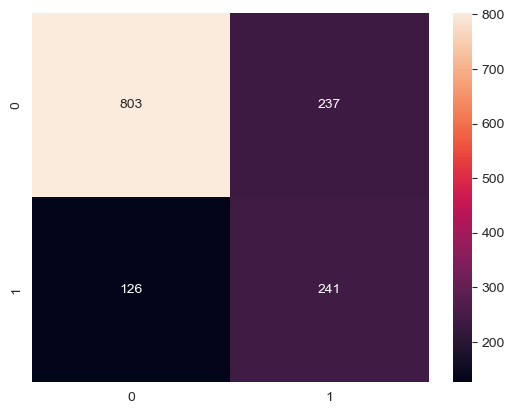

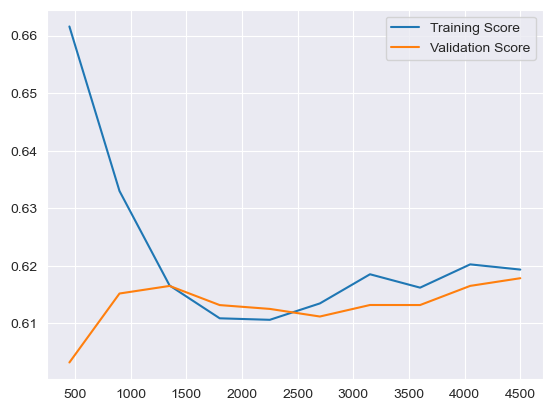


Evaluating K-Nearest Neighbors
              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1040
           1       0.56      0.47      0.51       367

    accuracy                           0.77      1407
   macro avg       0.69      0.67      0.68      1407
weighted avg       0.75      0.77      0.76      1407



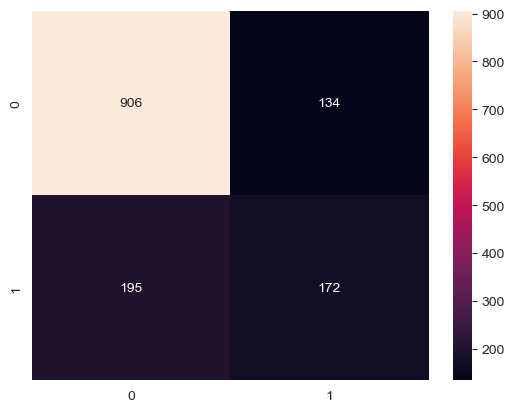

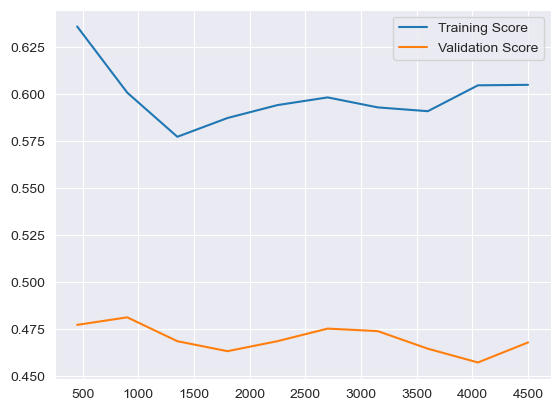


Evaluating Support Vector Machine
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1040
           1       0.69      0.37      0.48       367

    accuracy                           0.79      1407
   macro avg       0.75      0.65      0.67      1407
weighted avg       0.78      0.79      0.77      1407



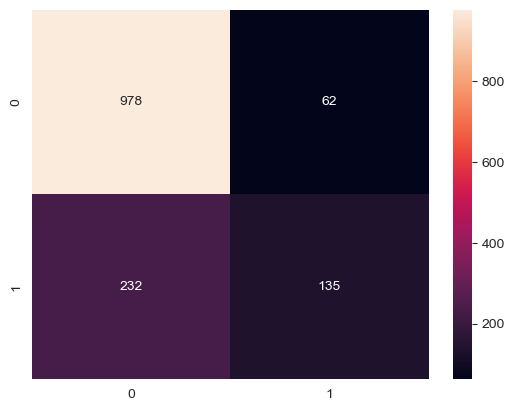

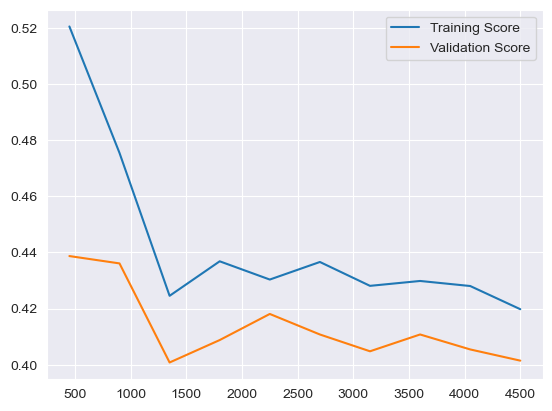


Evaluating Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      1040
           1       0.46      0.51      0.49       367

    accuracy                           0.72      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.73      0.72      0.72      1407



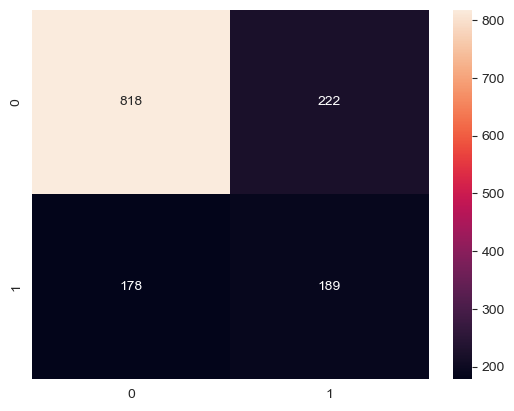

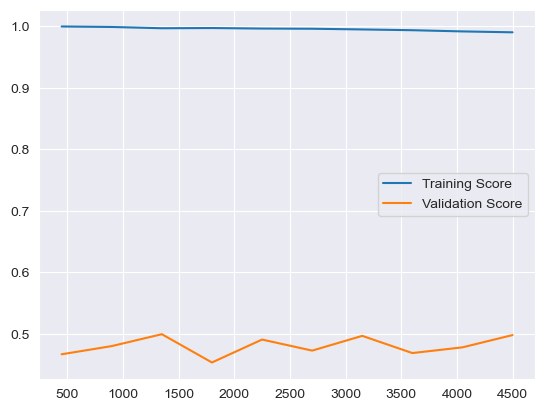


Evaluating Random Forest
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1040
           1       0.58      0.46      0.52       367

    accuracy                           0.77      1407
   macro avg       0.70      0.67      0.68      1407
weighted avg       0.76      0.77      0.76      1407



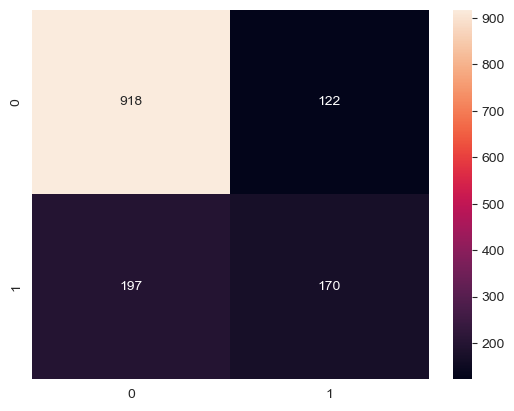

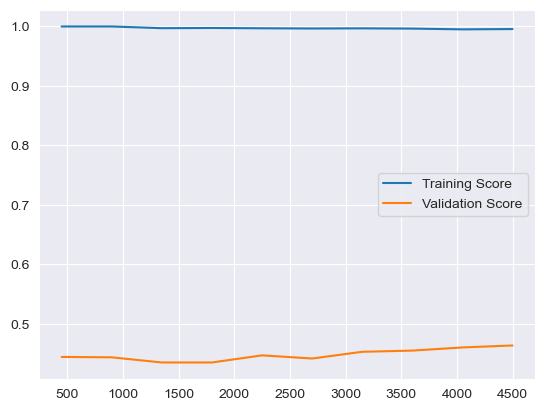


Evaluating AdaBoost
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1040
           1       0.66      0.47      0.55       367

    accuracy                           0.80      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.80      0.79      1407



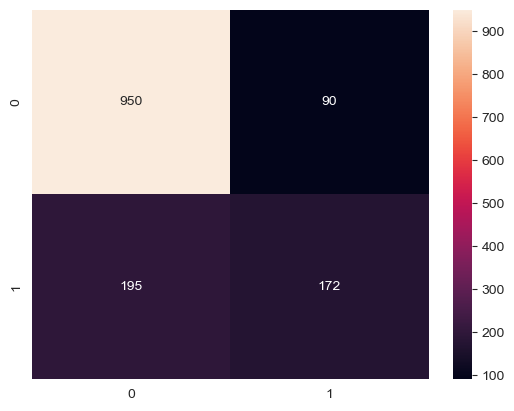

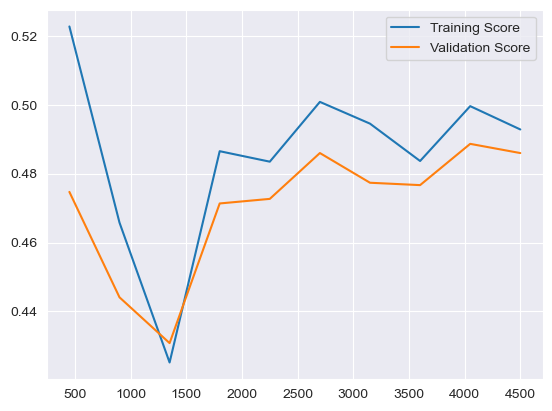


Evaluating GradientBoosting
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1040
           1       0.64      0.50      0.56       367

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



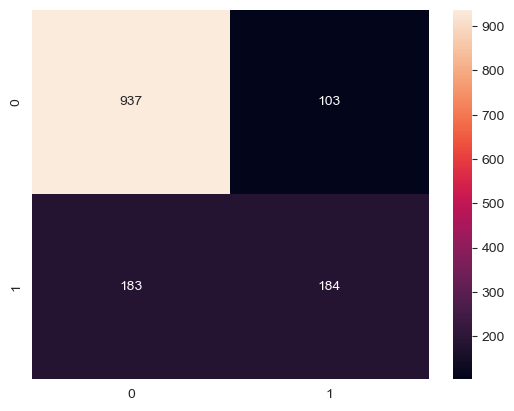

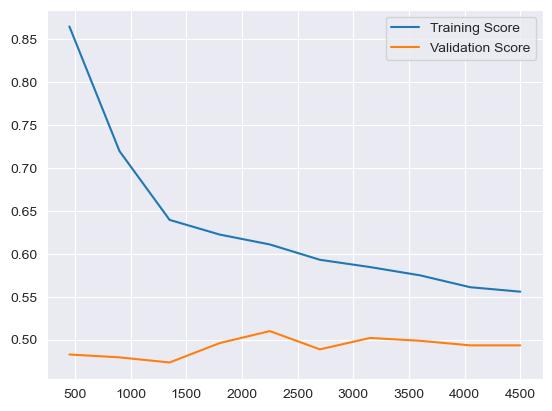


Evaluating Artificial Neural Network
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1040
           1       0.64      0.48      0.55       367

    accuracy                           0.80      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407



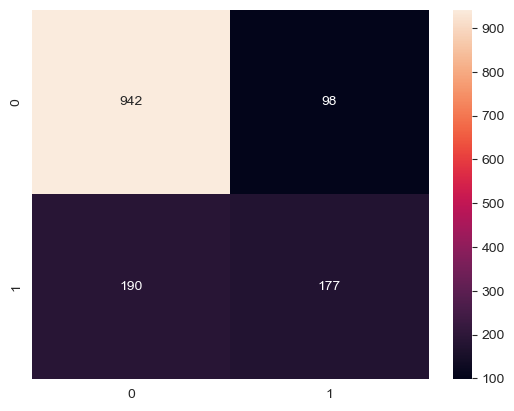

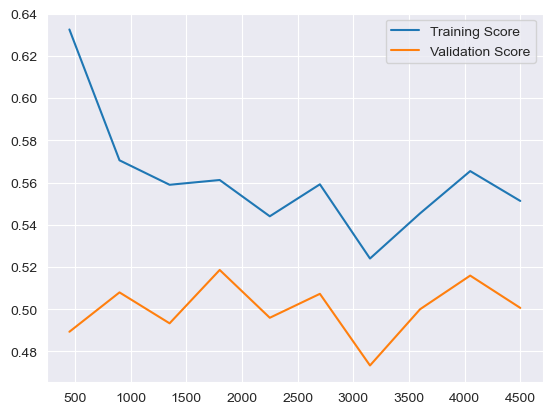

In [126]:
#Create Models Pipeline

#Ignore all warnings
warnings.filterwarnings("ignore")

gauss_model = make_pipeline(preprocessor, gauss)
knn_model = make_pipeline(preprocessor, knn)
svc_model = make_pipeline(preprocessor, svc)
tree_model = make_pipeline(preprocessor, tree)
forest_model = make_pipeline(preprocessor, forest)
adaboost_model = make_pipeline(preprocessor, adaboost)
gradient_boosting_model = make_pipeline(preprocessor, gradient_boosting)
ann_model = make_pipeline(preprocessor, ann)

#Regroup the model
ml_model = [gauss_model, knn_model, svc_model, tree_model, forest_model, adaboost_model, gradient_boosting_model, ann_model]

for name, model in zip(ml_names, ml_model):
    evaluation(model, name)


The best performing model:

        - K-Nearest Neighbors Acc: 0.77
        - Support Vector Machine Acc: 0.79
        - AdaBoost Acc: 0.80
        - GradientBoosting Acc: 0.80
        - Artificial Neural Network Acc: 0.80

## VII.Hyperparameter Tuning (GridSearchCV)

In [127]:
#Retrieve the model identification name inside the pipeline
for name , model in zip(ml_names, ml_model):
  print(f"{name:-<50} {model} ")
  print()

Gauss--------------------------------------------- Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('Num', StandardScaler(),
                                                  ['Tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('Cat', OrdinalEncoder(),
                                                  ['Gender', 'Partner',
                                                   'Dependents',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport',
                                                   'PaymentMethod'])])),
                ('gaussiannb', GaussianNB())]) 

K-Nearest Nei

In [128]:
#Create various model parameters to optimise

#K-Nearest Neighbors
knn_param_prefix = "kneighborsclassifier__"
knn_params_grid = {
    knn_param_prefix+"n_neighbors": range(1, 21),
    knn_param_prefix+"metric": ["euclidean", "manhattan"],
    knn_param_prefix+"weights": ["uniform", "distance"],
}


#Support Vector Machine
svc_param_prefix = "svc__"
svc_params_grid = {
    svc_param_prefix+"C": [0.1, 1, 10, 100, 1000],
    svc_param_prefix+"kernel": ["linear", "poly", "rbf", "sigmoid"],
    svc_param_prefix+"gamma": [1e-2, 1e-3, 1e-4],
    svc_param_prefix+"degree": [1, 3, 5, 7],
}

#AdaBoost
adaboost_param_prefix = "adaboostclassifier__"
adaboost_params_grid = {
    adaboost_param_prefix+"learning_rate": [0.1, 0.01, 0.001, 0.0001],
    adaboost_param_prefix+"n_estimators": [10, 20, 50, 100, 150, 200],
}

#GradientBoosting
gradient_boosting_param_prefix = "gradientboostingclassifier__"
gradient_boosting_params_grid = {
    gradient_boosting_param_prefix+"n_estimators": [10, 20, 50, 100, 150, 200],
    gradient_boosting_param_prefix+"learning_rate": [0.1, 0.01, 0.001, 0.0001],
}

#Artificial Neural Network
ann_model_param_prefix = "mlpclassifier__"
ann_model_params_grid = {
    ann_model_param_prefix+"hidden_layer_sizes": [100, 200, 300, 400, 500],
    ann_model_param_prefix+"activation": ["relu", "identity", "logistic", "tanh"],
    ann_model_param_prefix+"solver": ["sgd", "adam", "lbfgs"],
    ann_model_param_prefix+"learning_rate": ["constant", "invscaling", "adaptive"],
}


In [129]:
#Create the various model grid

#Parameters
grid_names = ["K-Nearest Neighbors", "Support Vector Machine", "AdaBoost", "Gradient Boosting", "Artificial Neural Network"]
grid_models = [knn_model, svc_model, adaboost_model, gradient_boosting_model, ann_model,]
grid_params = [knn_params_grid, svc_params_grid, adaboost_params_grid, gradient_boosting_params_grid, ann_model_params_grid]

In [130]:
#Plot Learning Curve Function
def plot_learning_curve(name: str, estimator):
    print(name)
    #Learning Curve to visualise the system perform
    N, train_score, val_score = learning_curve(estimator,
                                               X_train,
                                               y_train,
                                               train_sizes= np.linspace(0.1, 1.0, 10),
                                               cv= 5,
                                               scoring= "recall",
    )

    plt.figure()
    plt.title("Learning Curve")
    plt.plot(N, train_score.mean(axis= 1), label="Training Score")
    plt.plot(N, val_score.mean(axis= 1), label="Validation Score")
    plt.legend(loc="best")
    plt.show()
    print()

In [131]:
#Create Grid Model Evaluation Function
def grid_evaluation(name: str, model, param:dict):

    #Create the estimator
    model_grid = GridSearchCV(model,
                               param_grid= param,
                               scoring= "recall",
                               cv= 5, )

    #Train the estimator
    model_grid.fit(X_train, y_train)

    #Display Estimator Hyperparameter
    print(f"{name:-<50} {model_grid.best_params_}")
    print(f"{name:-<50} {model_grid.best_score_}")

    #Estimator Prediction
    y_pred = model_grid.predict(X_test)

    #Display Estimator Performance
    print(f"Recall: {recall_score(y_test, y_pred)}")
    print(f"Precision: {precision_score(y_test, y_pred)}")
    print(f"F1 Score: {f1_score(y_test, y_pred)}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred)}")
    print()

    #Display the Classification report
    print(f"{name}:\n"
          f"{classification_report(y_test, y_pred)}")
    print()

    return model_grid.best_estimator_


K-Nearest Neighbors------------------------------- {'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 1, 'kneighborsclassifier__weights': 'uniform'}
K-Nearest Neighbors------------------------------- 0.4920022148394242
Recall: 0.5149863760217984
Precision: 0.4772727272727273
F1 Score: 0.4954128440366973
ROC-AUC: 0.6579739572416685

K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1040
           1       0.48      0.51      0.50       367

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.65      1407
weighted avg       0.73      0.73      0.73      1407


K-Nearest Neighbors


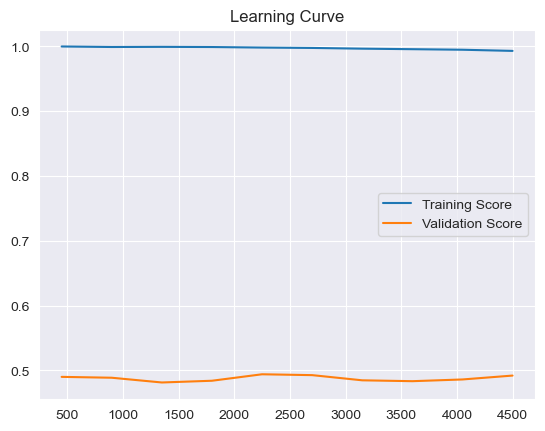


Support Vector Machine---------------------------- {'svc__C': 10, 'svc__degree': 1, 'svc__gamma': 0.01, 'svc__kernel': 'sigmoid'}
Support Vector Machine---------------------------- 0.5206267995570321
Recall: 0.49318801089918257
Precision: 0.6464285714285715
F1 Score: 0.5595054095826894
ROC-AUC: 0.6989978516034374

Support Vector Machine:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1040
           1       0.65      0.49      0.56       367

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.79      0.80      0.79      1407


Support Vector Machine


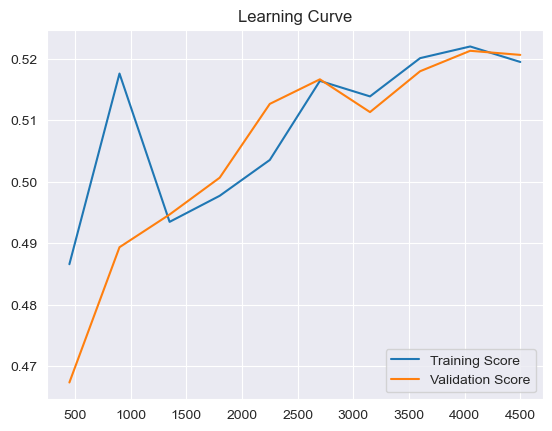


AdaBoost------------------------------------------ {'adaboostclassifier__learning_rate': 0.1, 'adaboostclassifier__n_estimators': 200}
AdaBoost------------------------------------------ 0.29562126245847176
Recall: 0.31607629427792916
Precision: 0.7295597484276729
F1 Score: 0.44106463878326996
ROC-AUC: 0.6373650702158877

AdaBoost:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      1040
           1       0.73      0.32      0.44       367

    accuracy                           0.79      1407
   macro avg       0.76      0.64      0.66      1407
weighted avg       0.78      0.79      0.76      1407


AdaBoost


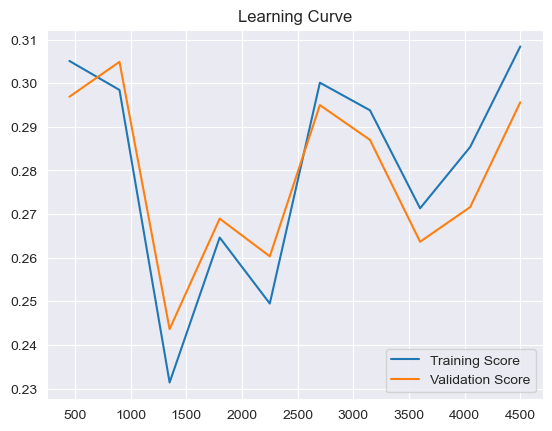


Gradient Boosting--------------------------------- {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__n_estimators': 200}
Gradient Boosting--------------------------------- 0.4999778516057587
Recall: 0.4986376021798365
Precision: 0.6245733788395904
F1 Score: 0.5545454545454546
ROC-AUC: 0.6964341857053029

Gradient Boosting:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1040
           1       0.62      0.50      0.55       367

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Gradient Boosting


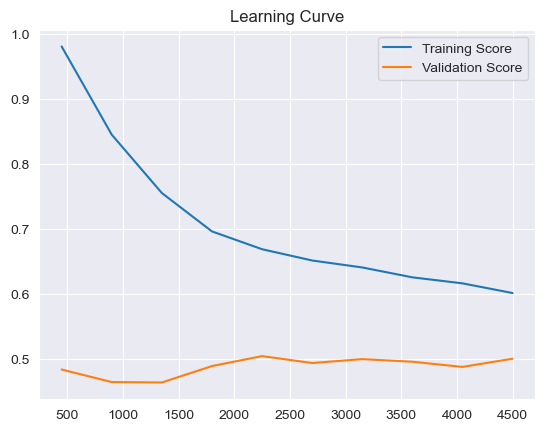


Artificial Neural Network------------------------- {'mlpclassifier__activation': 'identity', 'mlpclassifier__hidden_layer_sizes': 300, 'mlpclassifier__learning_rate': 'constant', 'mlpclassifier__solver': 'adam'}
Artificial Neural Network------------------------- 0.5286312292358805
Recall: 0.44141689373297005
Precision: 0.6454183266932271
F1 Score: 0.5242718446601942
ROC-AUC: 0.6779199853280234

Artificial Neural Network:
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1040
           1       0.65      0.44      0.52       367

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407


Artificial Neural Network


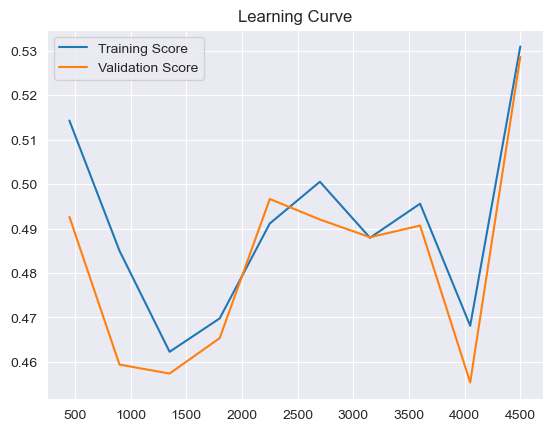

In [132]:
#Evaluate and retrieve the model best estimator
best_estimators = {}
for name, model, param in zip(grid_names, grid_models, grid_params):
    model = grid_evaluation(name, model, param)
    plot_learning_curve(name, model)
    best_estimators[name] = model

The model with the best performance are:

        - Support Vector Classifier (Accuracy: 0.520, Recall: 0.493, Precision: 0.646, F1 Score: 0.559,ROC-AUC: 0.699)
        has the best performance with no variance (overffiting) but does have some biais (underfitting).
        - Artificial Neural Network (Accuracy: 0.528, Recall: 0.441, Precision: 0.645, F1 Score: 0.524, ROC-AUC: 0.678)
        has on the best performance with biais and no variance.
        - Gradient Boosting (Accuracy: 0.499, Recall: 0.499, Precision: 0.625, F1 Score: 0.555, ROC-AUC: 0.696)
        has one the best performance with variance and biais.


## VIII.Precision Recall Curve

In [133]:
#Plot Precision Recall Curve Function
def precision_recall_curve_pipeline(name: str, pipeline: Pipeline):
    print(name)

    #Get the Classifier inside your pipeline
    model = pipeline.steps[-1][1]

    #Transformed (preprocess) data
    X_test_transformed = pipeline.steps[0][1].transform(X_test)

    # Use decision_function if available, else use predict_proba
    if hasattr(model, "decision_function"):
        model_predict = model.decision_function(X_test_transformed)
    else:
        model_predict = model.predict_proba(X_test_transformed)[:, 1]

    #Retrieve the precision, recall and threshold
    precision , recall, threshold = precision_recall_curve(y_test, model_predict)

    #Visualise the precision and recall in function of the threshold
    plt.figure()
    plt.plot(threshold, precision[:-1], label="Precision")
    plt.plot(threshold, recall[: -1], label="Recall")
    plt.legend()
    plt.show()

    print()


Support Vector Machine


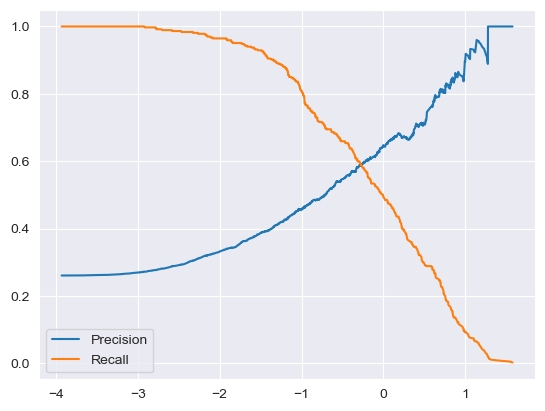


Gradient Boosting


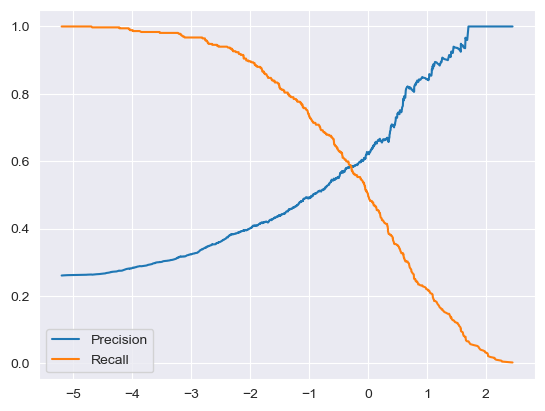


Artificial Neural Network


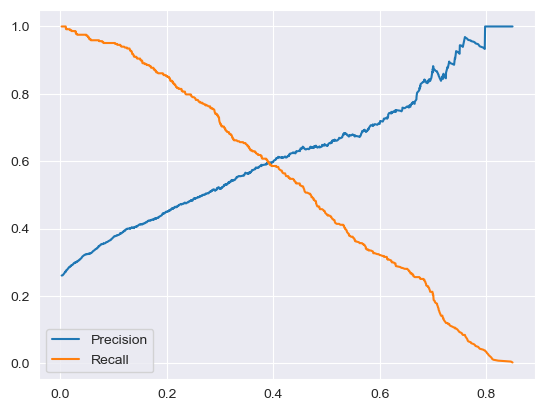

In [134]:
#Display the Precision Recall Curve
names = ["Support Vector Machine", "Gradient Boosting", "Artificial Neural Network"]
pipelines = [best_estimators[name] for name in names]
for name, pipeline in zip(names, pipelines):
    precision_recall_curve_pipeline(name, pipeline)

By modify the threshold, the recall performance can be optimised, but it will also decrease the precision, a comprised between both performance metrics must be found for each model:

    - SVC threshold: -1.5
    - Gradient Boosting: -2.5
    - Aritficial Neural Network: 0.20


### Threshold Fixing

In [135]:
#Create model with threshold
def threshold_pipeline(name, pipeline: Pipeline, X: pd.DataFrame, threshold: float = 0.0):
    print(name)

    #Get the Classifier inside your pipeline
    model = pipeline.steps[-1][1]

    #Transformed (preprocess) data
    X_transformed = pipeline.steps[0][1].transform(X)

    # Use decision_function if available, else use predict_proba
    if hasattr(model, "decision_function"):
        model_predict = model.decision_function(X_transformed)
    else:
        model_predict = model.predict_proba(X_transformed)[:, 1]

    y_pred = [1 if pred >= threshold else 0 for pred in model_predict]

    return y_pred

In [136]:
#Display the Precision Recall Curve
thresholds = [-1.5, -2.5, 0.20]
predictions = {}
for name, pipeline, threshold in zip(names, pipelines, thresholds):
    y_pred = threshold_pipeline(name, pipeline, X_test, threshold)
    predictions[name] = y_pred

Support Vector Machine
Gradient Boosting
Artificial Neural Network


In [137]:
#Model Performance Function
def model_performance(name, y_true: list | pd.Series, y_pred: list | pd.Series):
    print(name)
    print(classification_report(y_true, y_pred))
    print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
    print(f"F1      : {f1_score(y_true, y_pred)}")
    print(f"Recall  : {recall_score(y_true, y_pred)}")
    print()

In [138]:
#Display each estimator performance
for name in names:
    y_pred = predictions.get(name)
    model_performance(name, y_test, y_pred)


Support Vector Machine
              precision    recall  f1-score   support

           0       0.95      0.48      0.64      1040
           1       0.39      0.93      0.55       367

    accuracy                           0.60      1407
   macro avg       0.67      0.71      0.59      1407
weighted avg       0.80      0.60      0.62      1407

Accuracy: 0.5991471215351812
F1      : 0.5473515248796148
Recall  : 0.9291553133514986

Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.41      0.58      1040
           1       0.36      0.94      0.52       367

    accuracy                           0.55      1407
   macro avg       0.66      0.68      0.55      1407
weighted avg       0.80      0.55      0.56      1407

Accuracy: 0.5515280739161336
F1      : 0.522331566994701
Recall  : 0.9400544959128065

Artificial Neural Network
              precision    recall  f1-score   support

           0       0.92      0.63      0.75      

The best Machine Learning model is the Artificial Neural Network with a threshold equal to 0.20 by having the best compromise between accuracy (69%) and recall (85%).
The model have has average of right prediction equal to 69% and predict 85% of the churn customers.

Another option to optimise the prediction is to average the decision of each best models by a bagging method.

### Voting Classifier

In [139]:
#Create Bagging Model
bagging_model = VotingClassifier(
    estimators=[
        ("Support Vector Machine", svc_model.steps[-1][1]),
        ("Gradient Boosting", gradient_boosting_model.steps[-1][1]),
        ("Artificial Neural Network", ann_model.steps[-1][1]),
    ],
    voting="soft",
)
#Preprocess dataset
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

#Train the model
bagging_model.fit(X_train_transformed, y_train)
#Predict the output
y_pred_bagging = bagging_model.predict(X_test_transformed)

model_performance("Bagging Model", y_test, y_pred_bagging)

Bagging Model
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1040
           1       0.68      0.42      0.52       367

    accuracy                           0.80      1407
   macro avg       0.75      0.67      0.69      1407
weighted avg       0.78      0.80      0.78      1407

Accuracy: 0.7967306325515281
F1      : 0.5185185185185185
Recall  : 0.4196185286103542



The bagging model performance are outmatched by the others models (Support Vector Machine, Gradient Boosting and Artificial Neural Network) with a fix threshold.

## IX.Conclusion

The goal of this project was to develop a machine learning model capable of accurately predicting customer churn and providing actionable insights that support proactive retention strategies. Through comprehensive data preprocessing and model evaluation, we identified the key behavioral and demographic factors associated with churn and built a system that can reliably estimate churn risk at the individual customer level.

Multiple classification algorithms—including Support Vector Machines, Gradient Boosting, and others—were trained and compared using metrics such as precision, recall, F1-score, ROC-AUC, and precision–recall curves. Among the tested models, the Artificial Neural Network (Multi-Layer Perceptron) demonstrated the strongest overall performance, offering a robust balance between predictive accuracy and the ability to capture minority-class churn behavior (recall).

The analysis revealed that variables such as payment method, tenure, service usage patterns, partnership,  monthly and total charges were significant drivers of churn. These insights enable businesses to design targeted retention programs, prioritize high-risk customers, and reduce churn-related revenue loss.

In conclusion, the developed churn prediction model provides a valuable data-driven tool for anticipating customer attrition and informing strategic decision-making. With further enhancements—such as real-time scoring, integration into CRM systems, and monitoring model drift—the solution can evolve into a fully operational customer retention system capable of delivering long-term business impact.